In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/survey_data_20250821_135653.csv")
df.head()

,name,age,gender,income,Utilities,Entertainment,School Fees,Shopping,Healthcare
0,Prince Kwame,23,Male,5000.0,320.0,120.0,220.0,0.0,0.0
1,Prince Kwame,23,Male,5000.0,320.0,120.0,220.0,0.0,0.0
2,Albert Prince,26,Male,2500.0,1300.0,1000.0,0.0,0.0,0.0
3,Prince Kwame,23,Male,5000.0,0.0,0.0,0.0,0.0,0.0


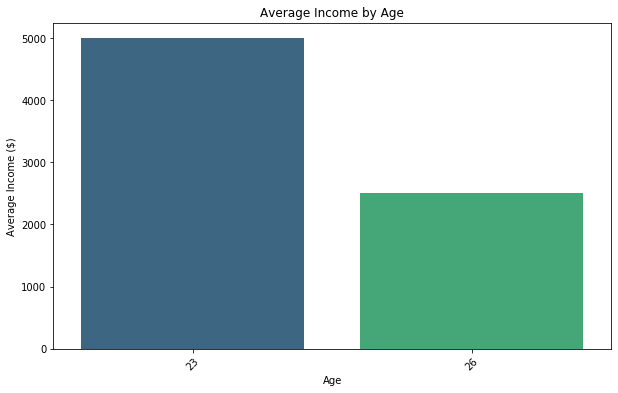

In [3]:
# Group by age and get average income
age_income = df.groupby("age")["income"].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=age_income.index, y=age_income.values, palette="viridis")
plt.title("Average Income by Age")
plt.xlabel("Age")
plt.ylabel("Average Income ($)")
plt.xticks(rotation=45)
plt.show()


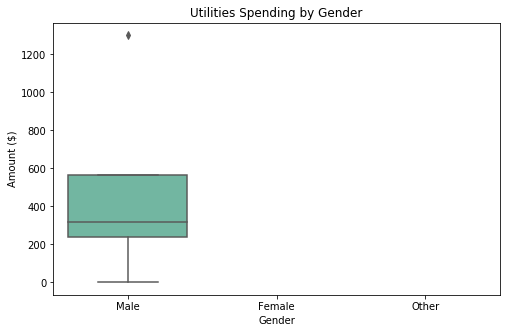

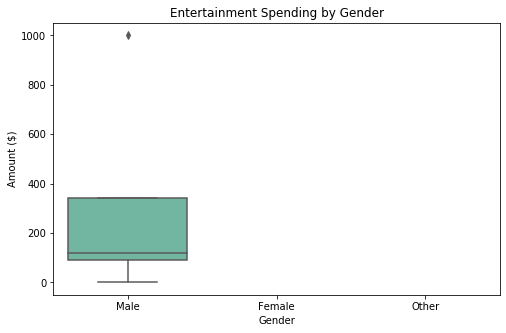

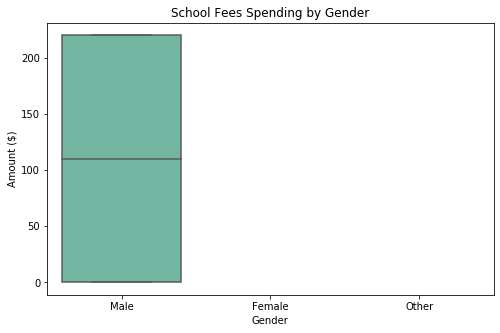

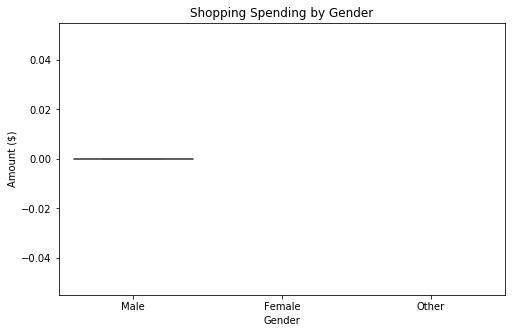

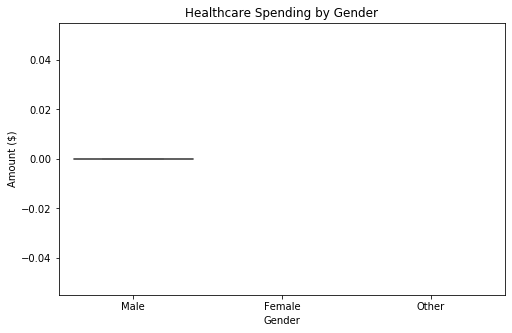

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

# Ensure charts folder exists
os.makedirs("charts", exist_ok=True)

# Clean gender column
df["gender"] = df["gender"].str.strip().str.capitalize()
gender_order = ["Male", "Female", "Other"]

expense_cols = ["Utilities", "Entertainment", "School Fees", "Shopping", "Healthcare"]

for col in expense_cols:
    plt.figure(figsize=(8,5))

    # Ensure numeric values
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    sns.boxplot(x="gender", y=col, data=df, order=gender_order, palette="Set2")
    plt.title(f"{col} Spending by Gender")
    plt.ylabel("Amount ($)")
    plt.xlabel("Gender")

    # Save chart for PowerPoint
    safe_col_name = col.replace(" ", "_").lower()
    plt.savefig(f"charts/{safe_col_name}_by_gender.png", bbox_inches="tight")
    plt.show()


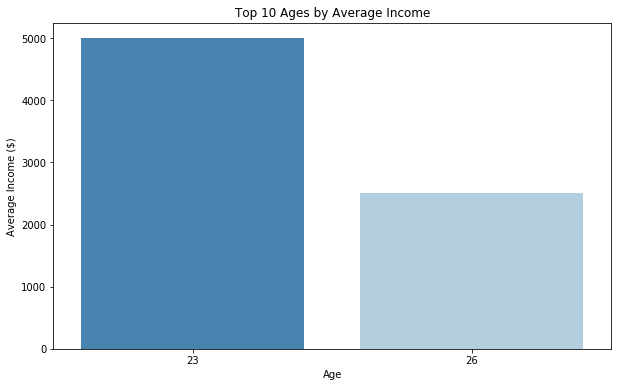

In [7]:
income_by_age = df.groupby("age")["income"].mean().reset_index()

income_by_age = income_by_age.sort_values(by="income", ascending=False)

# Plot top 10 ages with highest average income
top_n = 10
plt.figure(figsize=(10,6))
sns.barplot(
    x="age", 
    y="income", 
    data=income_by_age.head(top_n), 
    palette="Blues_r"
)
plt.title(f"Top {top_n} Ages by Average Income")
plt.ylabel("Average Income ($)")
plt.xlabel("Age")
plt.show()
